## Regression project: Working with real life data

## Context:

## In this section, a real life dataset centered around diamonds will be used in order to apply key Machine Learning and Regression techniques.

## The goal of this project is to build a solid Regression model which can predict diamond prices.

## Importing libraries and data

In [1]:
# Importing libraries
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Importing data
df = pd.read_csv('diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# One-hot encoding the cut column
df_dummies = pd.get_dummies(df, columns = ['cut'], dtype=int)
df_dummies.head()

,carat,color,clarity,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good
0,0.23,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0,0,1,0,0
1,0.21,E,SI1,59.8,61.0,326,3.89,3.84,2.31,0,0,0,1,0
2,0.23,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0,1,0,0,0
3,0.29,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0,0,0,1,0
4,0.31,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0,1,0,0,0


In [4]:
# Missing values?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
# Statistical information
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## Visualizing the carat and price of diamonds

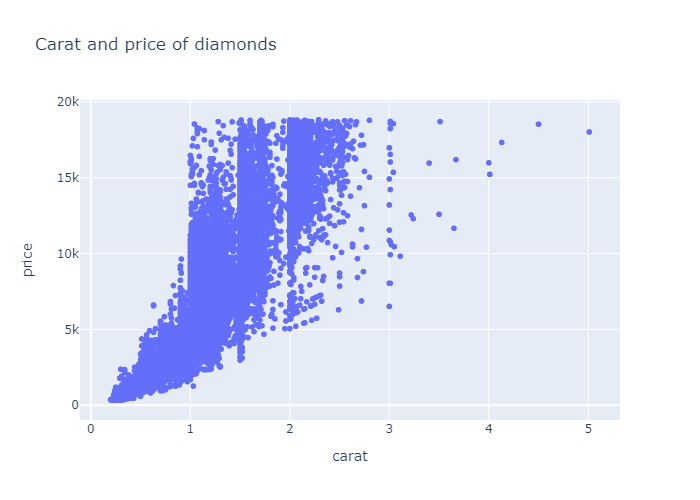

In [6]:
fig = px.scatter(df, x="carat", y="price", title="Carat and price of diamonds")
fig.show("png")

## Visualizing the depth and price of diamonds

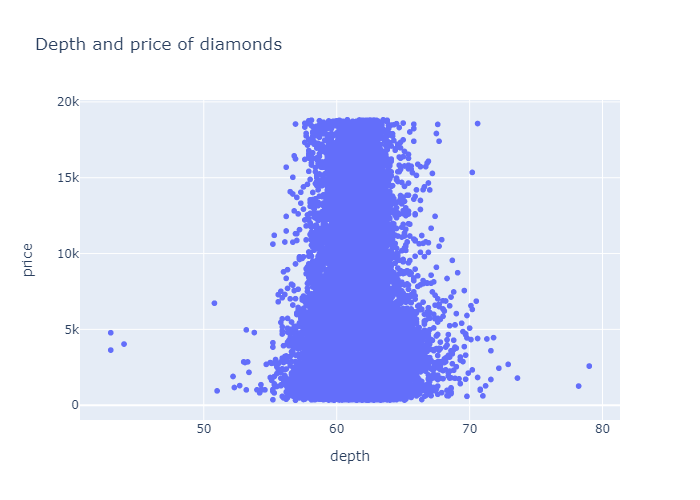

In [7]:
fig = px.scatter(df, x="depth", y="price", title="Depth and price of diamonds")
fig.show("png")

## Visualizing the table and price of diamonds

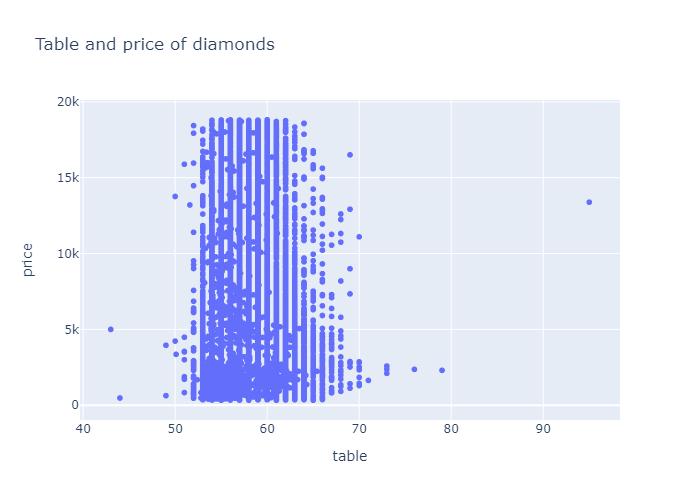

In [8]:
fig = px.scatter(df, x="table", y="price", title="Table and price of diamonds")
fig.show("png")

## Visualizing the length and price of diamonds

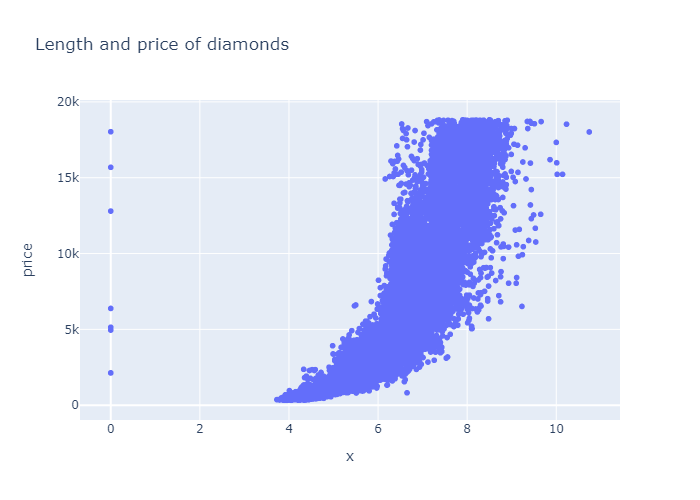

In [9]:
fig = px.scatter(df, x="x", y="price", title="Length and price of diamonds")
fig.show("png")

## Visualizing the width and price of diamonds

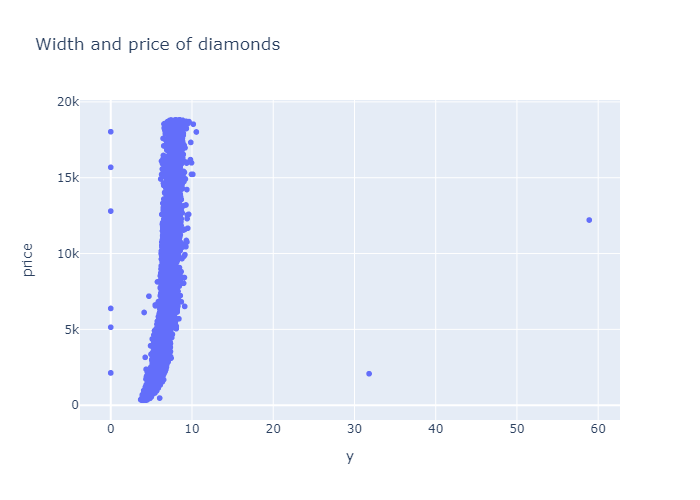

In [10]:
fig = px.scatter(df, x="y", y="price", title="Width and price of diamonds")
fig.show("png")

## Visualizing the height and price of diamonds

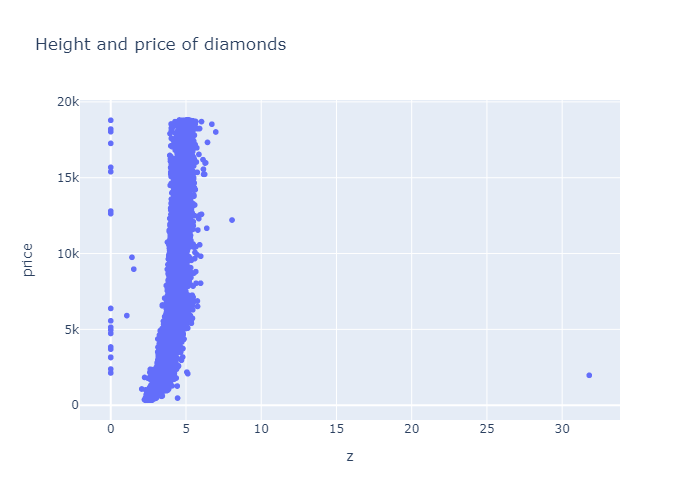

In [11]:
fig = px.scatter(df, x="z", y="price", title="Height and price of diamonds")
fig.show("png")

## Identifying correlations

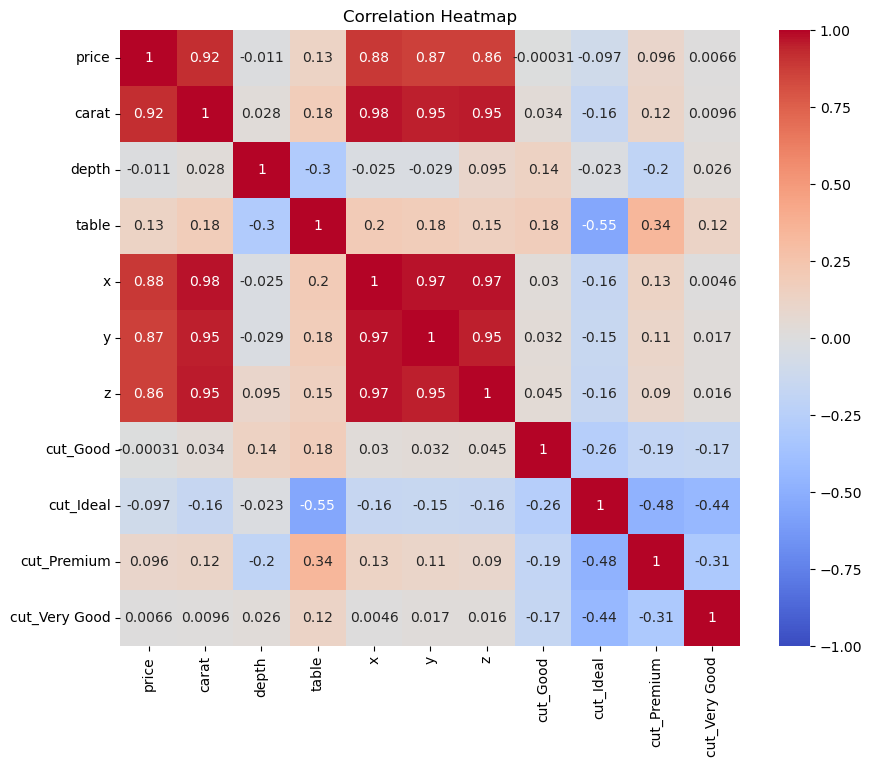

In [12]:
# Calculate the correlation matrix
correlation_matrix = df_dummies[['price', 'carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good']].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# Customize the heatmap
plt.title('Correlation Heatmap')
plt.show("png")

## The price of a diamond is mainly impacted by the weight and measurements.

## Since the weight of a diamond is determined by the measurements of a diamond, adding the weight and measurements as features also adds redundancy to the model. Using both features at the same time, is not required.

## The cut of a diamond doesn't correlate with the price of a diamond.

## Now, it's time to find the best model.

## Model 1: Linear Regression model using the weight

In [13]:
# Defining features
X = df[['carat']]
y = df[['price']]

# Generating an empty list
scores_linear_regression = []

for i in range(0, 100):

    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    # Instantiate model
    model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Generating predictions
    y_pred = model.predict(X_test)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_linear_regression.append(r2)

print('Using the weight as a feature, the average R² score of 100 Linear Regression trainings is:', sum(scores_linear_regression) / len(scores_linear_regression))

Using the weight as a feature, the average R² score of 100 Linear Regression trainings is: 0.8488086663722092



## Model 2: Linear Regression model using the measurements

In [14]:
# Defining features
X = df[['x', 'y', 'z']]
y = df[['price']]

# Generating an empty list
scores_linear_regression = []

for i in range(0, 100):

    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    # Instantiate model
    model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Generating predictions
    y_pred = model.predict(X_test)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_linear_regression.append(r2)

print('Using the dimensions as features, the average R² score of 100 Linear Regression trainings is:', sum(scores_linear_regression) / len(scores_linear_regression))

Using the dimensions as features, the average R² score of 100 Linear Regression trainings is: 0.7706767386442352


## Model 3: Polynomial Regression model using the weight

In [15]:
# Defining features
X = df[['carat']]
y = df[['price']]

# Instantiate polynomial features
pf = PolynomialFeatures(degree=2, include_bias=False)

# Generating an empty list
scores_polynomial_regression = []

for i in range(0, 100):
    
    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)
    
    # Transforming X_train and X_test for the Polynomial Regression
    X_train_poly = pf.fit_transform(X_train)
    X_test_poly = pf.transform(X_test)  # Only transform the test set
    
    # Instantiate model
    model = LinearRegression()

    # Training the model on X_train_poly
    model.fit(X_train_poly, y_train)

    # Generating predictions
    y_pred = model.predict(X_test_poly)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_polynomial_regression.append(r2)

print('Using the weight as a feature, the average R² score of 100 Polynomial Regression trainings is:', sum(scores_polynomial_regression) / len(scores_polynomial_regression))

Using the weight as a feature, the average R² score of 100 Polynomial Regression trainings is: 0.8506451245990618


## Model 4: Polynomial Regression model using the measurements

In [16]:
# Defining features
X = df[['x', 'y', 'z']]
y = df[['price']]

# Generating an empty list
scores_polynomial_regression = []

# Instantiate polynomial features
pf = PolynomialFeatures(degree=2, include_bias=False)

for i in range(0, 100):
    
    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)
    
    # Transforming X_train and X_test for the Polynomial Regression
    X_train_poly = pf.fit_transform(X_train)
    X_test_poly = pf.transform(X_test)  # Only transform the test set
    
    # Instantiate model
    model = LinearRegression()

    # Training the model on X_train_poly
    model.fit(X_train_poly, y_train)

    # Generating predictions
    y_pred = model.predict(X_test_poly)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_polynomial_regression.append(r2)

print('Using the measurements as features, the average R² score of 100 Polynomial Regression trainings is:', sum(scores_polynomial_regression) / len(scores_polynomial_regression))

Using the measurements as features, the average R² score of 100 Polynomial Regression trainings is: -26.95163175185319


## Conclusion:

## Both the Linear and Polynomial Regression perform well if the weight of a diamond is used as a feature.

## Using the measurements as features didn't increase the R² score of the Linear Regression model and vastly decreased the model accuracy of the Polynomial Regression. 

## The best performing model was Model 3: Polynomial Regression using the weight with an R² score of 0.85